# MINE4201 - SR - Taller 1 - Preparación de los datos

**Grupo 3**

Lina María Ojeda Amaya Código: 202112324

Diego Felipe Tolosa Código: 201413235

Juan Manuel Rivera López Código: 201534131

Johana Alejandra Rátiva Mora Código: 202513844

# Importación de librerías y datos

In [2]:
import numpy as np
import os
import pandas as pd
import random
from matplotlib import pyplot as plt
import time

from scipy.sparse import csr_matrix

from sklearn.preprocessing import normalize
from tqdm import tqdm

#Para garantizar reproducibilidad en resultados
seed = 10
random.seed(seed)
np.random.seed(seed)

In [3]:
base_path = "C:/Users/jmriv/OneDrive - Universidad de los andes/Semestres uniandes/2026-1/Sistemas de recomendación/Talleres"
links_path = os.path.join(base_path, "link.csv")
movies_path = os.path.join(base_path, "movie.csv")
ratings_path = os.path.join(base_path, "rating.csv")

In [4]:
ratings = pd.read_csv(ratings_path)
ratings.head()

,userId,movieId,rating,timestamp
0,1,2,3.5,2005-04-02 23:53:47
1,1,29,3.5,2005-04-02 23:31:16
2,1,32,3.5,2005-04-02 23:33:39
3,1,47,3.5,2005-04-02 23:32:07
4,1,50,3.5,2005-04-02 23:29:40


In [5]:
movies = pd.read_csv(movies_path)
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


# Análisis exploratorio de los datos

In [20]:
print(f"El conjunto tiene información de {movies.shape[0]} películas")
print(f"Hay ratings para {len(ratings['movieId'].unique())} películas")

El conjunto tiene información de 27278 películas
Hay ratings para 26744 películas


## Análisis por ratings

In [29]:
ratings.rating.describe()

count    2.000026e+07
mean     3.525529e+00
std      1.051989e+00
min      5.000000e-01
25%      3.000000e+00
50%      3.500000e+00
75%      4.000000e+00
max      5.000000e+00
Name: rating, dtype: float64

In [28]:
ratings.rating.unique()

array([3.5, 4. , 3. , 4.5, 5. , 2. , 1. , 2.5, 0.5, 1.5])

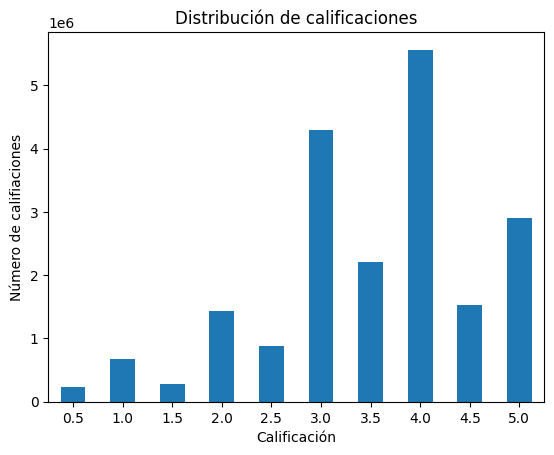

In [22]:
counts = ratings.rating.value_counts().sort_index()
counts.plot(kind='bar')
plt.xlabel('Calificación')
plt.ylabel('Número de califiaciones')
plt.title('Distribución de calificaciones')
plt.xticks(rotation=0)
plt.show()

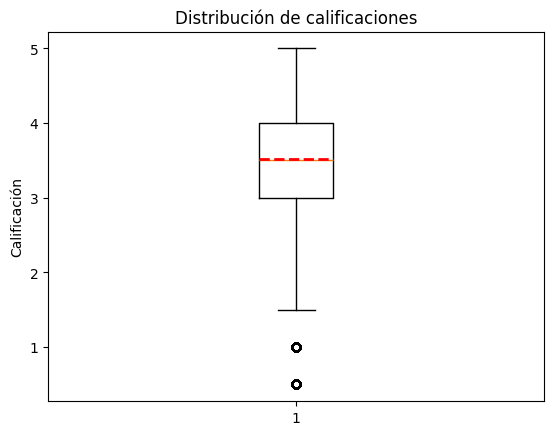

In [27]:
plt.boxplot(
    ratings.rating,
    showmeans=True,
    meanline=True,
    meanprops=dict(color='red', linewidth=2)
)

plt.ylabel('Calificación')
plt.title('Distribución de calificaciones')
plt.show()

Vemos que las calificaciones están discretizadas en intervalos de 0.5, y tienen valores entre 0.5 y 5.

Adicionalmente, el 75% superior de las calificaciones son superiores a 3

## Análisis de ratings agrupados por usuario

In [34]:
ratings_by_user = ratings.groupby('userId')['rating'].agg({'count','mean'}).sort_values(by='count', ascending=False)
ratings_by_user.head()

,count,mean
userId,,
118205,9254,3.279069
8405,7515,3.208317
82418,5646,3.516915
121535,5520,2.793116
125794,5491,3.762976


In [35]:
ratings_by_user.describe()

,count,mean
count,138493.000000,138493.000000
mean,144.413530,3.627209
std,230.267257,0.443030
min,20.000000,0.500000
25%,35.000000,3.369478
50%,68.000000,3.653846
75%,155.000000,3.923077
max,9254.000000,5.000000


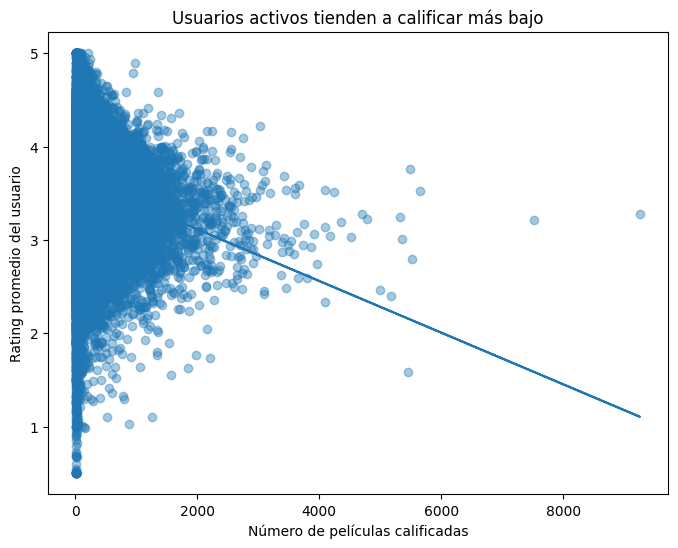

In [32]:
user_stats = ratings.groupby('userId')['rating'].agg(['count','mean']).round(2)

x = user_stats['count']
y = user_stats['mean']

plt.figure(figsize=(8,6))
plt.scatter(x, y, alpha=0.4)

# línea de tendencia
coef = np.polyfit(x, y, 1)
poly1d_fn = np.poly1d(coef)
plt.plot(x, poly1d_fn(x))

plt.xlabel("Número de películas calificadas")
plt.ylabel("Rating promedio del usuario")
plt.title("Usuarios activos tienden a calificar más bajo")
plt.show()

Text(0.5, 1.0, 'Distribución del número de ratings realizados por cada usuario')

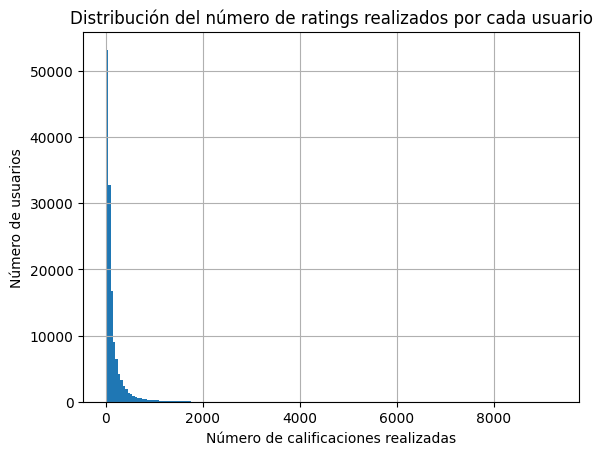

In [40]:
hist = ratings_by_user['count'].hist(bins= range(0, ratings_by_user['count'].max() + 50, 50))
hist.set_xlabel('Número de calificaciones realizadas')
hist.set_ylabel('Número de usuarios')
hist.set_title('Distribución del número de ratings realizados por cada usuario')

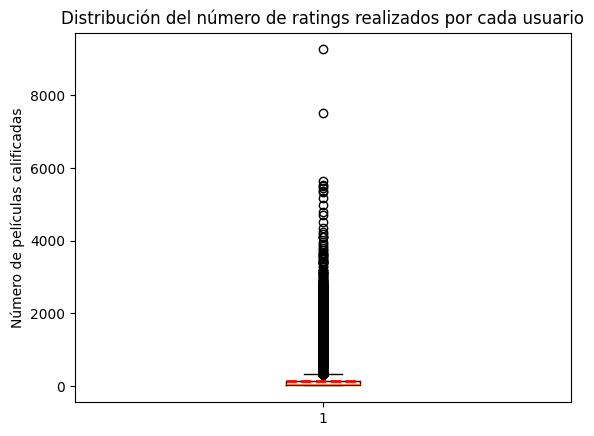

In [42]:
plt.boxplot(
    ratings_by_user['count'],
    showmeans=True,
    meanline=True,
    meanprops=dict(color='red', linewidth=2)
)

plt.ylabel("Número de películas calificadas")
plt.title("Distribución del número de ratings realizados por cada usuario")
plt.show()

Text(0.5, 1.0, 'Distribución del las calificaciones promedio realizadas por usuario')

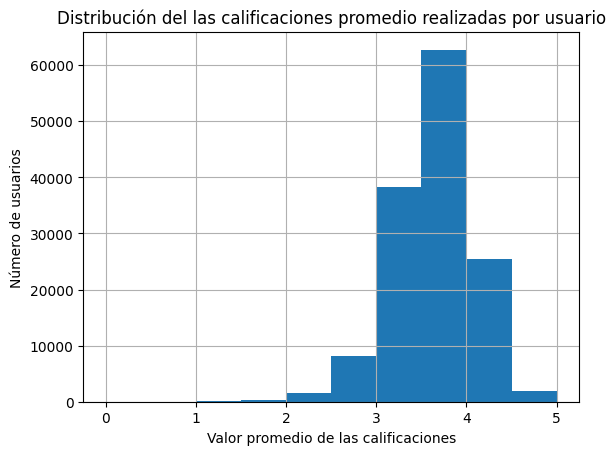

In [43]:
hist = ratings_by_user['mean'].hist(bins= np.arange(0, 5.5, 0.5))
hist.set_xlabel('Valor promedio de las calificaciones')
hist.set_ylabel('Número de usuarios')
hist.set_title('Distribución del las calificaciones promedio realizadas por usuario')


## Análaisis de ratings agrupados por película

In [45]:
movies.columns

Index(['movieId', 'title', 'genres'], dtype='object')

In [47]:
ratings_by_movie = ratings.groupby('movieId')['rating'].agg({'count','mean','var'}).merge(
    movies[['movieId', 'title']],
    left_on='movieId',
    right_on='movieId',
    how='left'
)
ratings_by_movie.head()

,movieId,count,var,mean,title
0,1,49695,0.790342,3.921240,Toy Story (1995)
1,2,22243,0.904686,3.211977,Jumanji (1995)
2,3,12735,1.013328,3.151040,Grumpier Old Men (1995)
3,4,2756,1.200563,2.861393,Waiting to Exhale (1995)
4,5,12161,0.964598,3.064592,Father of the Bride Part II (1995)


In [48]:
ratings_by_movie.describe()

,movieId,count,var,mean
count,26744.000000,26744.000000,22772.000000,26744.000000
mean,58789.612436,747.841123,0.946540,3.133200
std,44159.344871,3085.818268,0.650142,0.664084
min,1.000000,1.000000,0.000000,0.500000
25%,6795.750000,3.000000,0.607546,2.800000
50%,65880.000000,18.000000,0.875000,3.235294
75%,99110.500000,205.000000,1.144425,3.565217
max,131262.000000,67310.000000,10.125000,5.000000


In [49]:
ratings_by_movie.sort_values('count', ascending=False).head(15)

,movieId,count,var,mean,title
293,296,67310,0.952725,4.174231,Pulp Fiction (1994)
352,356,66172,0.898737,4.029000,Forrest Gump (1994)
315,318,63366,0.514842,4.446990,"Shawshank Redemption, The (1994)"
587,593,63299,0.709673,4.177057,"Silence of the Lambs, The (1991)"
476,480,59715,0.860847,3.664741,Jurassic Park (1993)
257,260,54502,0.843682,4.190672,Star Wars: Episode IV - A New Hope (1977)
108,110,53769,0.912136,4.042534,Braveheart (1995)
583,589,52244,0.815566,3.931954,Terminator 2: Judgment Day (1991)
2486,2571,51334,0.788417,4.187186,"Matrix, The (1999)"
523,527,50054,0.681320,4.310175,Schindler's List (1993)


Text(0.5, 1.0, 'Distribución del número de ratings recibidos por película')

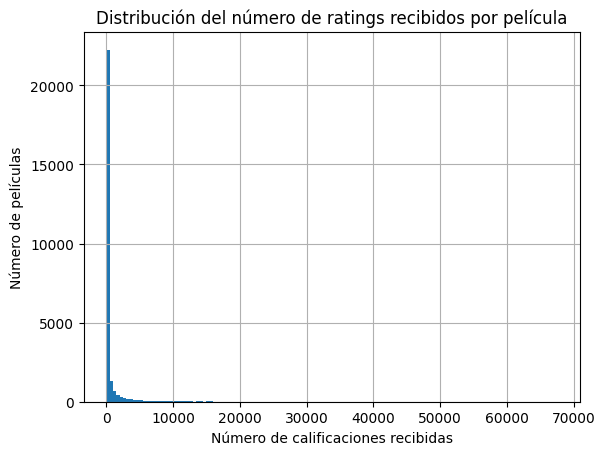

In [52]:
hist = ratings_by_movie['count'].hist(bins= range(0, ratings_by_movie['count'].max() + 500, 500))
hist.set_xlabel('Número de calificaciones recibidas')
hist.set_ylabel('Número de películas')
hist.set_title('Distribución del número de ratings recibidos por película')

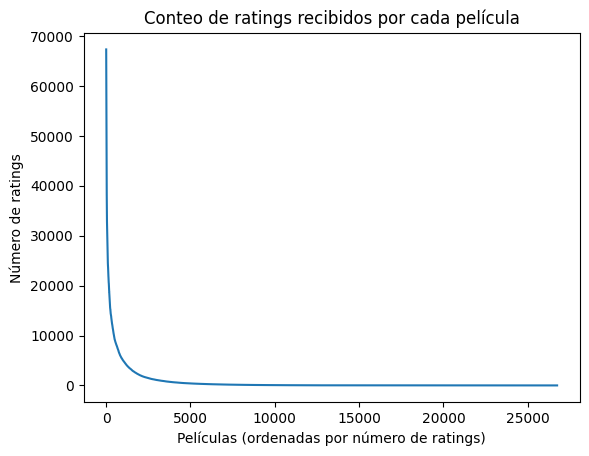

In [55]:
df_sorted = ratings_by_movie.sort_values('count', ascending=False)

# Create rank index (position)
df_sorted["rank"] = range(1, len(df_sorted) + 1)

# Plot long tail
plt.figure()
plt.plot(df_sorted["rank"], df_sorted["count"])
plt.title("Conteo de ratings recibidos por cada película")
plt.xlabel("Películas (ordenadas por número de ratings)")
plt.ylabel("Número de ratings")
plt.show()

In [57]:
def bayesian_average(movie_average, movie_n, global_average, threshold):
    return (movie_n / (movie_n + threshold)) * movie_average  + (threshold / (movie_n + threshold)) * global_average

In [58]:
global_average = ratings['rating'].mean()
threshold = np.percentile(ratings_by_movie['count'], 25)

In [62]:
ratings_by_movie["weighted_mean"] = ratings_by_movie.apply(
    lambda x: bayesian_average(
        x["mean"],
        x["count"],
        global_average,
        threshold
    ),
    axis=1
)
ratings_by_movie.sort_values('weighted_mean', ascending=False).head(20)

,movieId,count,var,mean,title,weighted_mean
315,318,63366,0.514842,4.446990,"Shawshank Redemption, The (1994)",4.446947
843,858,41355,0.705393,4.364732,"Godfather, The (1972)",4.364671
49,50,47006,0.572721,4.334372,"Usual Suspects, The (1995)",4.334321
523,527,50054,0.681320,4.310175,Schindler's List (1993),4.310128
23694,113315,11,0.250000,4.500000,Zero Motivation (Efes beyahasei enosh) (2014),4.291185
1195,1221,27398,0.747358,4.275641,"Godfather: Part II, The (1974)",4.275558
1935,2019,11611,0.701326,4.274180,Seven Samurai (Shichinin no samurai) (1954),4.273986
887,904,17449,0.566462,4.271334,Rear Window (1954),4.271205
7356,7502,4305,0.820357,4.263182,Band of Brothers (2001),4.262669
895,912,24349,0.745426,4.258327,Casablanca (1942),4.258237


In [61]:
ratings_by_movie.sort_values('weighted_mean', ascending=False).tail(10)

,movieId,count,var,mean,title,weighted_mean
9754,31698,467,0.910266,1.252677,Son of the Mask (2005),1.267184
22343,107704,11,0.040909,0.590909,Justin Bieber's Believe (2013),1.219756
6266,6371,325,1.350651,1.167692,Pokémon Heroes (2003),1.189258
1746,1826,419,0.784812,1.163484,Barney's Great Adventure (1998),1.180276
6477,6587,701,0.833763,1.164051,Gigli (2003),1.174114
12003,54290,180,1.217846,1.105556,Bratz: The Movie (2007),1.145227
4679,4775,685,0.687796,1.124088,Glitter (2001),1.134559
6373,6483,426,0.672799,0.973005,From Justin to Kelly (2003),0.990855
7170,7282,29,0.349754,0.724138,"Hip Hop Witch, Da (2000)",0.986768
8176,8859,209,0.612831,0.837321,SuperBabies: Baby Geniuses 2 (2004),0.875361


# Separación en conjunto de entrenamiento y evaluación

In [6]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,2,3.5,2005-04-02 23:53:47
1,1,29,3.5,2005-04-02 23:31:16
2,1,32,3.5,2005-04-02 23:33:39
3,1,47,3.5,2005-04-02 23:32:07
4,1,50,3.5,2005-04-02 23:29:40


In [7]:
test = ratings.groupby("userId", group_keys=False).sample(frac=0.2, random_state=42)
train = ratings.drop(test.index)

In [8]:
print(len(train))
print(len(test))

16001027
3999236


# Construcción de la matriz de utilidad

In [9]:
user_cat = train.userId.astype("category")
item_cat = train.movieId.astype("category")

user_ids = user_cat.cat.codes
item_ids = item_cat.cat.codes

R_train = csr_matrix(
    (train.rating, (user_ids, item_ids))
)

In [10]:
R_train.data = R_train.data.astype(np.float32)

In [ ]:
user_map = dict(zip(user_cat.cat.categories, range(len(user_cat.cat.categories))))
item_map = dict(zip(item_cat.cat.categories, range(len(item_cat.cat.categories))))

# Búsqueda de vecinos

In [12]:
def precompute_top_k_neighbors(R, K=100, metric="cosine", batch_size=1000):
    """
    Computes and stores the top K neighbors for each row in R in batches.
    Returns two arrays of shape (N, K): one for neighbor indices, one for similarity scores.
    """
    N = R.shape[0]
    
    # Pre-allocate lightweight arrays for results. This grants all users have an existing row
    top_k_indices = np.zeros((N, K), dtype=np.int32)
    top_k_sims = np.zeros((N, K), dtype=np.float32)

    # Pre-process matrices based on the metric
    t0 = time.time()
    if metric == "cosine":
        R_processed = normalize(R, axis=1)
    elif metric == "pearson":
        R_processed = R.copy()
        counts = np.diff(R_processed.indptr)
        sums = np.add.reduceat(R_processed.data, R_processed.indptr[:-1])
        means = sums / counts
        R_processed.data -= np.repeat(means, counts)
        R_processed = normalize(R_processed, axis=1)

    elif metric == "jaccard":
        B = R.copy()
        B.data = np.ones_like(B.data) # Binary matrix for Jaccard
        row_sums = np.array(B.sum(axis=1)).flatten() # Count of non-zero ítems in the row
    print("Normalization:", time.time() - t0)

    # Process in batches to save RAM (e.g., 1000 rows at a time)
    t0 = time.time()
    for start_idx in tqdm(range(0, N, batch_size), desc=f"Computing {metric} in batches", position=1):
        end_idx = min(start_idx + batch_size, N)
        
        # 1. Calculate similarity for the current batch
        if metric in ["cosine", "pearson"]:
            # Returns a sparse matrix of size (batch_size, N)
            batch_sim_sparse = R_processed[start_idx:end_idx] @ R_processed.T
            
        elif metric == "jaccard":
            B_batch = B[start_idx:end_idx]
            batch_sim_sparse = B_batch @ B.T # Calculate the union

        for i in range(batch_sim_sparse.shape[0]):

            row = batch_sim_sparse.getrow(i)

            sims = row.data
            indices = row.indices

            u = start_idx + i
            mask = indices != u
            indices = indices[mask]
            sims = sims[mask]

            if len(sims) == 0:
                top_k_indices[start_idx+i, 0] = -1
                top_k_sims[start_idx+i, 0] = -1
                continue

            if metric == 'jaccard':
                unions = row_sums[u] + row_sums[indices] - sims
                sims = sims / unions

            k = min(K, len(sims))

            top_idx = np.argpartition(-sims, k-1)[:k] # Finds the top K neighbour's positions for the user, without ordering

            top_k_indices[start_idx+i, :k] = indices[top_idx]
            top_k_sims[start_idx+i, :k] = sims[top_idx]
    print("Total time:", time.time() - t0)

    return top_k_indices, top_k_sims

In [ ]:
for metric in tqdm(["cosine", "pearson", "jaccard"], desc="Similarity metric", leave=False):

    top_indices, top_sims = precompute_top_k_neighbors(R_train, K=100, metric=metric )
    
    # Save the arrays to disk so you don't have to recalculate them if the kernel restarts
    np.savez_compressed(f"users_{metric}_top100_neighbors.npz", indices=top_indices, sims=top_sims)

Similarity metric:   0%|          | 0/1 [00:00<?, ?it/s]

Normalization: 0.8881878852844238


Computing pearson in batches: 100%|██████████| 139/139 [48:48<00:00, 21.06s/it]


Total time: 2928.0168120861053


In [ ]:
R_items = R_train.T
for metric in tqdm(["cosine", "pearson", "jaccard"], desc="Similarity metric", leave=False):
    top_indices, top_sims = precompute_top_k_neighbors(R_items, K=100, metric=metric )
    
    # Save the arrays to disk so you don't have to recalculate them if the kernel restarts
    np.savez_compressed(f"items_{metric}_top100_neighbors.npz", indices=top_indices, sims=top_sims)

Similarity metric:   0%|          | 0/1 [00:00<?, ?it/s]

Normalization: 0.1051795482635498


Computing jaccard in batches: 100%|██████████| 26/26 [17:01<00:00, 39.28s/it]


Total time: 1021.3632683753967


In [13]:
N = R_train.shape[0]

counts = np.diff(R_train.indptr)
sums = np.add.reduceat(R_train.data, R_train.indptr[:-1])
means = sums / counts

In [9]:
for metric in tqdm(["cosine", "pearson", "jaccard"], desc="Similarity metric", leave=False):
    for content in ['users', 'items']:
        with np.load(f"Train_neighbours/{content}_{metric}_top100_neighbors.npz") as data:
            indices = data["indices"]
            sims = data["sims"]

        order = np.argsort(-sims, axis=1)

        sorted_indices = np.take_along_axis(indices, order, axis=1)
        sorted_sims = np.take_along_axis(sims, order, axis=1)

        np.savez(
            f"Train_neighbours/{content}_{metric}_top100_neighbors.npz",
            indices=sorted_indices,
            sims=sorted_sims
        )


Similarity metric:   0%|          | 0/3 [00:00<?, ?it/s]